# Paper Figures

This notebook aims to reproduce the figures from/used in the paper.

In [15]:
import numpy as np

Make sure to run `pip install -e .` before running the cell below. This command will make sure `diet4cola` is installed as a module in your current Python/Conda environment.

In [16]:
from diet4cola.mask import *
from diet4cola.noise import *
from diet4cola.operations import *
from diet4cola.utils import *

In [17]:
seed = 10
width = 512
height = 512

## Synthetic Cells

### Generation

In [18]:
fractal_n = fractal_snoise(get_snoise_generator(seed), width, height, 0.005, 1)
worley_n = worley_noise(width, height, 256, seed)

In [19]:
np.random.seed(seed)
off_x = 256 + (np.random.randint(32) - 16)
off_y = 256 + (np.random.randint(32) - 16)

cell_mask_layer, (cell_extent_a, cell_extent_b), cell_angle = cell_mask(width, height, (off_x, off_y), (200, 200), 50, seed)

In [20]:
#myosin_layer = myosin_noise(width, height, seed = seed, iterations=10)
#myosin_layer = mul(myosin_layer, cell_mask_layer)

In [21]:
#actin_layer = actin_noise(width, height, cell_mask_layer, 2560, -0.05, seed)
#actin_layer = mul(actin_layer, cell_mask_layer)

In [22]:
#actomyosin_layer = add(myosin_layer, actin_layer)
#actomyosin_layer = normalize(actomyosin_layer)

In [23]:
#save_cortex(actomyosin_layer, './data/cortex_2.npy')

In [24]:
actomyosin_layer = load_cortex('./data/cortex_2.npy')

### Visualization

In [25]:
cmap = 'gray'

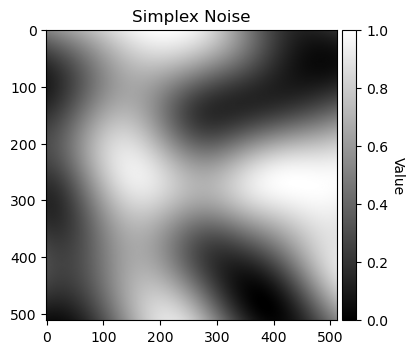

In [26]:
plot_2d_array(fractal_n, 'Simplex Noise', cmap)

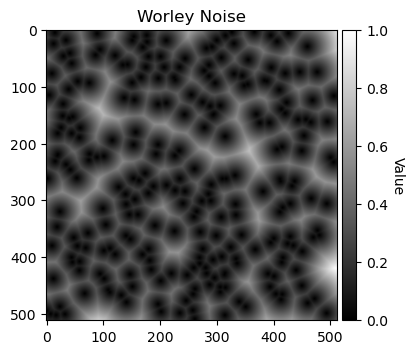

In [27]:
plot_2d_array(worley_n, 'Worley Noise', cmap)

In [28]:
save_2d_array(fractal_n, './data/simplex_example.png', cmap)
save_2d_array(worley_n, './data/worley_example.png', cmap)

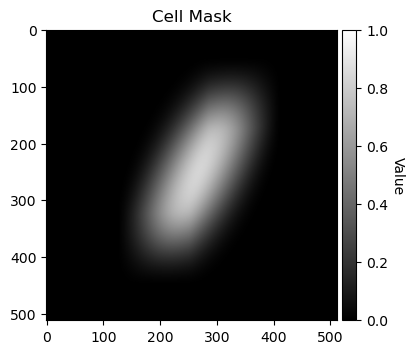

In [29]:
plot_2d_array(cell_mask_layer, 'Cell Mask', cmap)

In [30]:
save_2d_array(cell_mask_layer, './data/cell_mask_example.png', cmap)

In [31]:
#plot_2d_array(myosin_layer, 'Myosin', cmap)

In [32]:
#save_2d_array(myosin_layer, './data/myosin_example.png', cmap)

In [33]:
#plot_2d_array(actin_layer, 'Actin', cmap)

In [34]:
#save_2d_array(actin_layer, './data/actin_example.png', cmap)

In [35]:
#save_2d_array(invert(cell_mask_layer), './data/cell_mask_inverted_example.png', cmap)

In [36]:
#save_2d_array(invert(myosin_layer), './data/myosin_inverted_example.png', cmap)
#save_2d_array(invert(actin_layer), './data/actin_inverted_example.png', cmap)

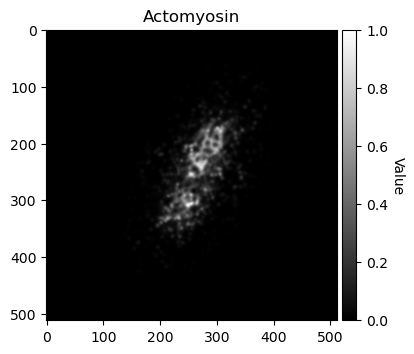

In [37]:
plot_2d_array(actomyosin_layer, 'Actomyosin', cmap)

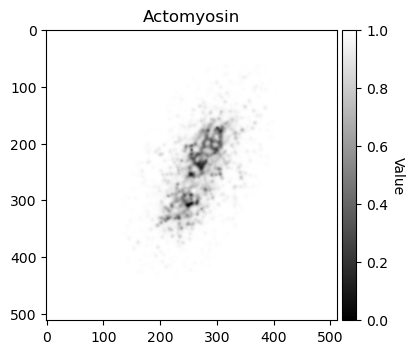

In [38]:
plot_2d_array(invert(actomyosin_layer), 'Actomyosin', cmap)

In [39]:
save_2d_array(actomyosin_layer, './data/actomyosin_example.png', cmap)
save_2d_array(invert(actomyosin_layer), './data/actomyosin_inverted_example.png', cmap)

## Synthetic Cut

In [ ]:
from diet4cola.cut import *

def plot_synthetic_cut_crosses(data: np.ndarray,
                       cut_center: tuple[int, int],
                       cut_origin: tuple[int, int],
                       cut_destination: tuple[int, int],
                       filename: str,
                       cmap: str = 'gray',
                       min: float = 0,
                       max: float = 1) -> None:
    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(np.ones((data.shape)), cmap=cmap, vmin=min, vmax=max)
    ax.set_title('Synthetic Cut')
    
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(im, cax=cax)  # pass the AxesImage, not the array
    cbar.set_label('Value', rotation=270, labelpad=12)

    ax.plot(
        [cut_origin[0], cut_destination[0]], 
        [cut_origin[1], cut_destination[1]], 
        color='black', linewidth=1, label='Cut', zorder=1, linestyle='--'
    )
    
    ax.scatter(cut_origin[0], cut_origin[1], color='Red', s=40, marker='x', label='Cut Origin', zorder=2)
    ax.scatter(cut_destination[0], cut_destination[1], color='blue', s=40, marker='x', label='Cut Destination', zorder=2)
    
    ax.legend(loc='upper right', fontsize=8)
    
    if filename:
        # Remove axes, colorbar, and title
        ax.set_axis_off()
        ax.set_title('')
        # Remove colorbar if it exists
        for c in fig.axes:
            if c is not ax:
                fig.delaxes(c)
        plt.margins(0)
        ax.set_position([0, 0, 1, 1])
        plt.savefig(filename, bbox_inches='tight', pad_inches=0)
        plt.close(fig)
    else:
        # Keep axes, title, and colorbar for interactive display
        ax.set_title('Synthetic Cut')
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label('Value', rotation=270, labelpad=12)
        plt.show()

In [27]:
cola_cut = CoLACut((off_x, off_y), 32, 200, seed + 1)

plot_synthetic_cut_crosses(actomyosin_layer, 
                   cola_cut.cut_center, 
                   cola_cut.cut_origin,
                   cola_cut.cut_destination, './data/cut_example', cmap=cmap)

## Velocity Field

In [28]:
from diet4cola.sdf import *

In [ ]:
from matplotlib import patheffects

def save_sdf_array(data: np.ndarray, filename: str, cmap: str = 'gray', levels: list[float] = [0]) -> None:
    fig, ax = plt.subplots()

    im = ax.imshow(data, cmap=cmap, aspect='equal', interpolation='nearest')

    # Overlay contour lines
    if levels is not None:
        cs = ax.contour(data, levels=levels, colors='white', linewidths=1.0)

        # Label contours with distance values
        clabels = ax.clabel(
            cs,
            fmt=lambda x: f"{x:.2f}",   # format contour labels
            inline=True,               # keep labels off the lines
            fontsize=9,
            colors='white',
        )

        # Add outline (path effect) for better visibility
        for txt in clabels:
            txt.set_path_effects([
                patheffects.Stroke(linewidth=1.5, foreground='black', alpha=0.7),
                patheffects.Normal()
            ])

    # Remove borders, axes, margins
    ax.axis('off')
    plt.margins(0)
    ax.set_position([0, 0, 1, 1])  # fill entire figure

    plt.savefig(filename, bbox_inches='tight', pad_inches=0)
    plt.close(fig)

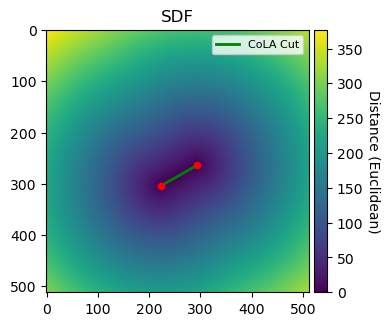

In [60]:
cut_sdf = compute_sdf(width, height, cola_cut.cut_origin, cola_cut.cut_destination, 0, True, sdf_segment)
plot_sdf(cut_sdf, cola_cut.cut_origin, cola_cut.cut_destination, cmap='viridis')

In [67]:
save_sdf_array(cut_sdf, './data/cut_sdf_example.png', 'viridis')

In [47]:
t_min = 0
t_max = 10
iterations = 20

# From t_min, t_max, iterations, compute step
time_step = (t_max - t_min) / iterations

# Create time points
timepoints = np.arange(t_min, t_max, time_step)

In [73]:
k = 0.5
initial_velocities = np.array([np.exp(-t * k) for t in timepoints])
parameter = 100
radius = 50
parameters = np.array([parameter] * iterations)
radii = np.linspace(0, radius, iterations)
widths = invert(initial_velocities) * 5


In [ ]:
from diet4cola.velocity import *

In [75]:
rounded_sdf_fields = compute_rounded_sdf_multi(512, 512, cola_cut.cut_origin, cola_cut.cut_destination, widths, radii, False, sdf_box, iterations)
masked_sdf_fields = np.array([mask_on_condition(sdf < 0, 0, 1) for sdf in rounded_sdf_fields])
clipped_rounded_sdf_fields = np.array([mask_on_condition(sdf < 0, 0, sdf) for sdf in rounded_sdf_fields])
velocity_fields = compute_velocity_field_multi(clipped_rounded_sdf_fields, prior_exponential, timepoints, initial_velocities, parameters, iterations)

100%|██████████| 20/20 [00:03<00:00,  5.50it/s]


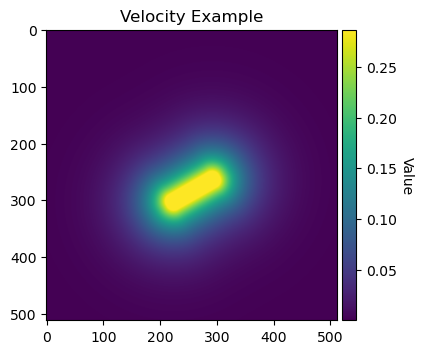

In [76]:
i=5
plot_2d_array(velocity_fields[i, :, :], 'Velocity Example', 'viridis', np.min(velocity_fields[i, :, :]), np.max(velocity_fields[i, :, :]))

In [78]:
save_2d_array(velocity_fields[i, :, :], './data/velocity_example.png', 'viridis')